# Data parsing and exploration for learnedcache

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
import numpy as np
import csv
import glob
from pathlib import Path

In [2]:
def read_csvs_to_dataframe(file_pattern: str) -> pd.DataFrame:
    """
    Reads multiple CSV files and concatenates them into a single dataframe.
    Adds a trial_id column based on the sequence in which files are loaded.
    """
    filepaths = glob.glob(file_pattern)
    dataframes = []
    for trial_id, filepath in enumerate(filepaths):
        df = pd.read_csv(filepath)
        df['trial_id'] = trial_id
        dataframes.append(df)
    combined_df = pd.concat(dataframes, ignore_index=True)
    
    return combined_df


In [3]:
df = read_csvs_to_dataframe('data/fileserver/*4_amended_access.csv')

In [4]:
df.head()

,a,t,d,i,o,s,z,f,trial_id
0,516266249654500,1555096763,253:0,786436,0,0,181829504,1000,0
1,516266249707366,1555147275,253:0,786436,1,0,181829504,1000,0
2,516266249709229,1555146903,253:0,786436,2,1,181829504,1000,0
3,516266249711042,1555146472,253:0,786436,3,1,181829504,1000,0
4,516266249712555,1555145271,253:0,786436,4,1,181829504,1000,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11511970 entries, 0 to 11511969
Data columns (total 9 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   a         int64 
 1   t         int64 
 2   d         object
 3   i         int64 
 4   o         int64 
 5   s         int64 
 6   z         int64 
 7   f         int64 
 8   trial_id  int64 
dtypes: int64(8), object(1)
memory usage: 790.5+ MB


In [6]:
pd.set_option('display.precision', 5)
df.describe()

,a,t,i,o,s,z,f,trial_id
count,1.15120e+07,1.15120e+07,1.15120e+07,1.15120e+07,1.15120e+07,1.15120e+07,1.15120e+07,11511970.0
mean,5.16297e+14,7.38024e+08,9.22061e+05,2.65585e+01,9.95194e-01,2.21182e+05,2.89839e+03,0.0
std,1.73799e+10,7.05500e+08,2.37022e+03,5.27910e+01,6.91619e-02,7.00377e+05,1.06281e+03,0.0
min,5.16266e+14,0.00000e+00,7.86436e+05,0.00000e+00,0.00000e+00,2.44000e+02,1.00000e+03,0.0
25%,5.16282e+14,3.85697e+08,9.20050e+05,8.00000e+00,1.00000e+00,1.19640e+05,2.19600e+03,0.0
50%,5.16297e+14,5.00665e+08,9.22077e+05,2.00000e+01,1.00000e+00,1.91629e+05,2.85200e+03,0.0
75%,5.16312e+14,9.59266e+08,9.24062e+05,3.70000e+01,1.00000e+00,2.87520e+05,3.55900e+03,0.0
max,5.16328e+14,6.36006e+10,9.26083e+05,3.40630e+04,1.00000e+00,1.81830e+08,9.78100e+03,0.0


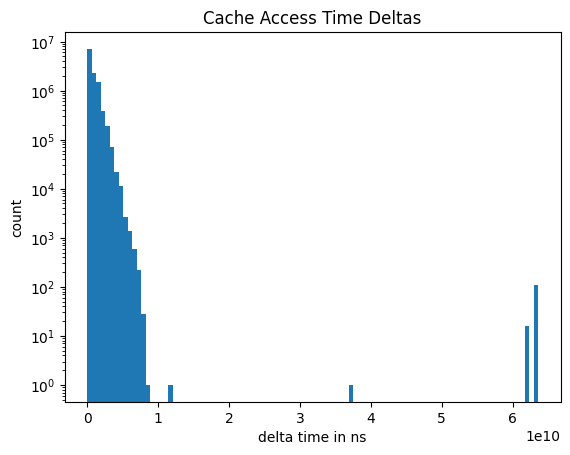

In [7]:
df['t'].plot(title='Cache Access Time Deltas', ylabel='count', xlabel="delta time in ns", kind='hist', bins=100)
plt.yscale('log')
plt.show()

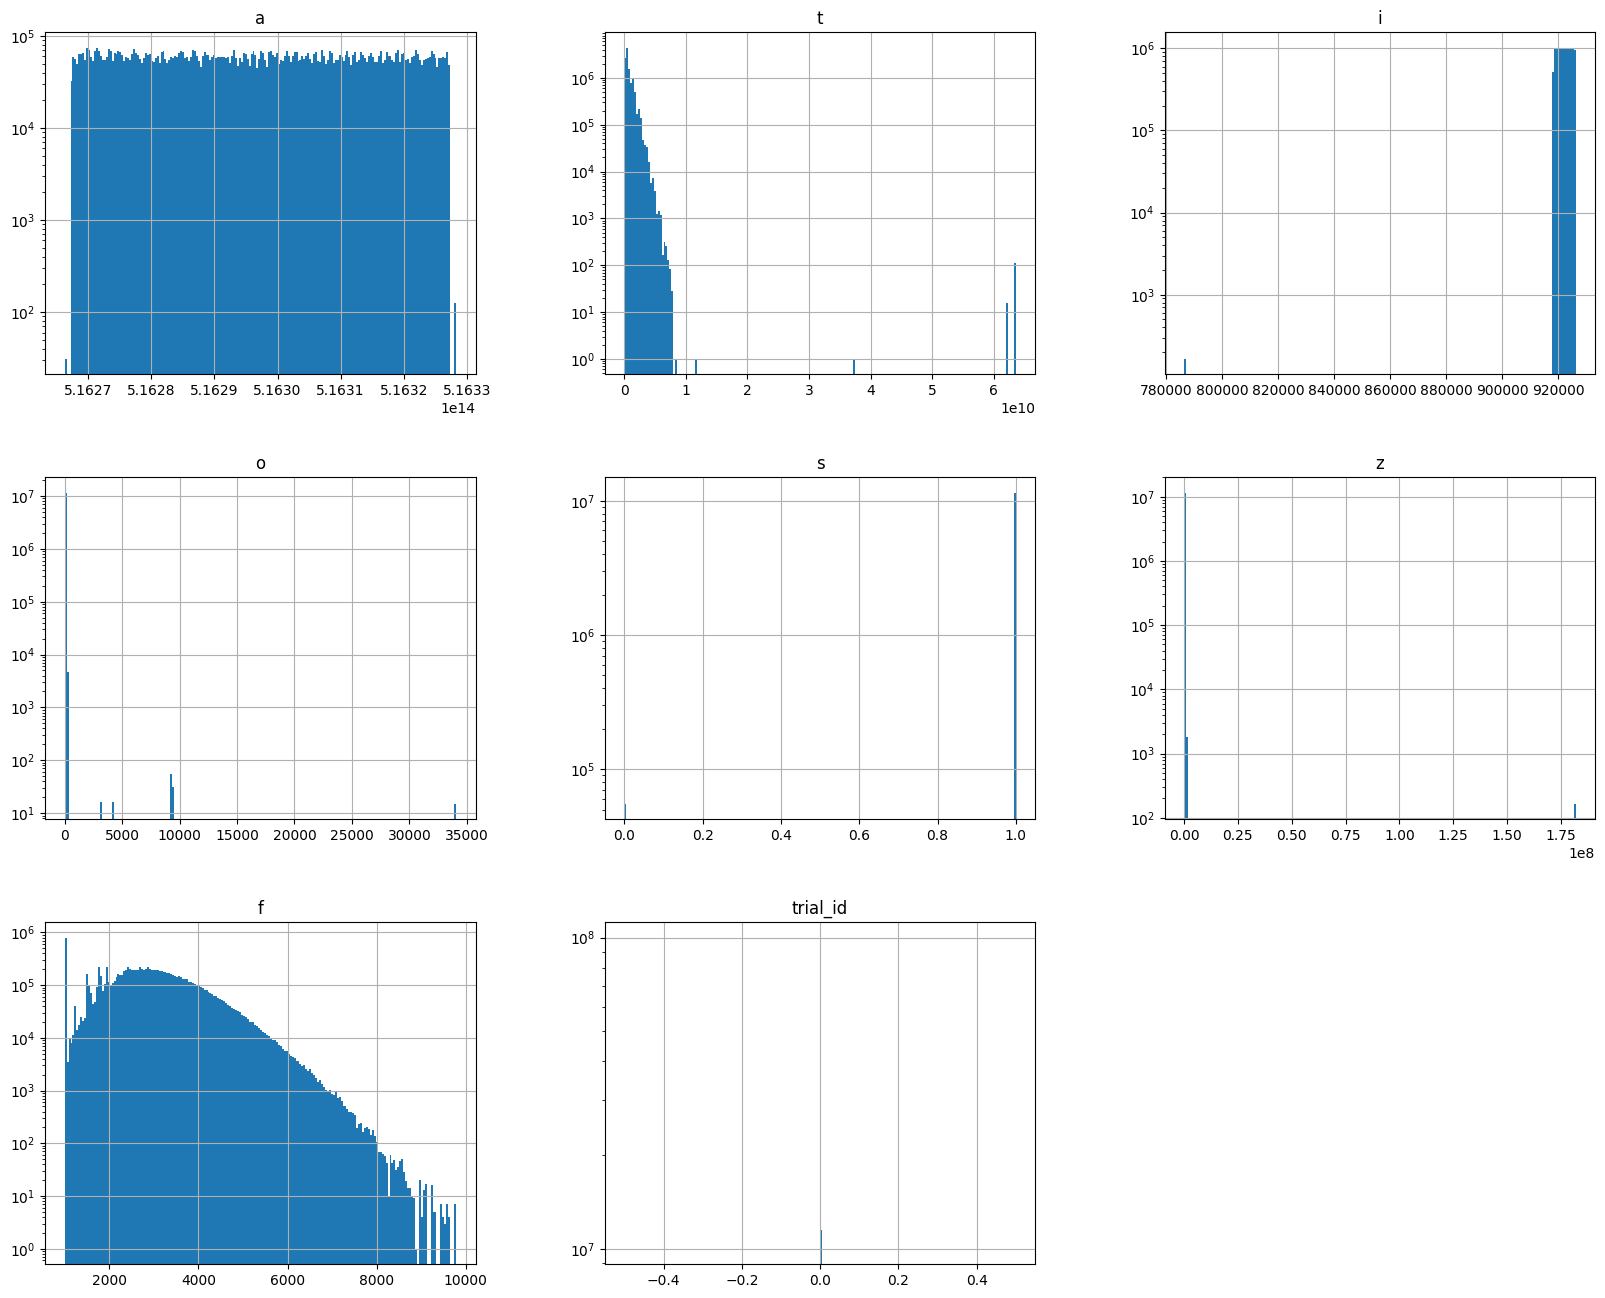

In [8]:
df.hist(figsize=(20,16), bins=200, log=True)
plt.show()

In [9]:
def train_and_transform_discretizer(
    X_train: pd.DataFrame,
    n_bins: int = 5,
    encode: str = 'ordinal',
    strategy: str = 'quantile',
    subsample: int | None = None,
    random_state: int | None = None
) -> tuple[pd.DataFrame, KBinsDiscretizer]:
    """
    Train a KBinsDiscretizer on the training dataset and return the transformed dataframe.
    
    Parameters
    ----------
    X_train : pd.DataFrame
        Training dataset to fit and transform
    n_bins : int, default=5
        Number of bins to produce. Must be >= 2.
    encode : {'onehot', 'onehot-dense', 'ordinal'}, default='ordinal'
        Method used to encode the transformed result.
        - 'onehot': Encode the transformed result with one-hot encoding
        - 'onehot-dense': Same as 'onehot' but returns dense array
        - 'ordinal': Return the bin identifier encoded as an integer value
    strategy : {'uniform', 'quantile', 'kmeans'}, default='quantile'
        Strategy used to define the widths of the bins.
        - 'uniform': All bins have identical widths
        - 'quantile': All bins have the same number of points
        - 'kmeans': Values in each bin have the same nearest center of a 1D k-means cluster
    subsample : int or None, default=None
        Maximum number of samples used to fit the model. If None, all samples are used.
    random_state : int or None, default=None
        Random state for reproducibility when using 'kmeans' strategy.
    
    Returns
    -------
    tuple[pd.DataFrame, KBinsDiscretizer]
        A tuple containing:
        - Transformed dataframe with discretized values
        - Fitted KBinsDiscretizer object for future transformations
    
    Examples
    --------
    >>> import pandas as pd
    >>> X_train = pd.DataFrame({'feature1': [1, 2, 3, 4, 5], 'feature2': [10, 20, 30, 40, 50]})
    >>> X_transformed, discretizer = train_and_transform_discretizer(X_train, n_bins=3)
    >>> print(X_transformed)
    """
    discretizer = KBinsDiscretizer(
        n_bins=n_bins,
        encode=encode,
        strategy=strategy,
        subsample=subsample,
        random_state=random_state,
        quantile_method='averaged_inverted_cdf',
    )

    X_transformed = discretizer.fit_transform(X_train)
    
    X_transformed_df = pd.DataFrame(
        X_transformed,
        columns=X_train.columns,
        index=X_train.index
    )
    
    return X_transformed_df, discretizer


In [10]:
featureset_df, discretizer = train_and_transform_discretizer(df[['t', 'z', 'f']], n_bins=10, strategy='quantile')
featureset_df.describe()

,t,z,f
count,1.15120e+07,1.15120e+07,1.15120e+07
mean,4.50000e+00,4.50018e+00,4.50159e+00
std,2.87228e+00,2.87225e+00,2.87176e+00
min,0.00000e+00,0.00000e+00,0.00000e+00
25%,2.00000e+00,2.00000e+00,2.00000e+00
50%,4.50000e+00,5.00000e+00,5.00000e+00
75%,7.00000e+00,7.00000e+00,7.00000e+00
max,9.00000e+00,9.00000e+00,9.00000e+00


In [11]:
n_bins_list = [len(discretizer.bin_edges_[i]) - 1 for i in range(3)]
n_bins_list

[10, 10, 10]

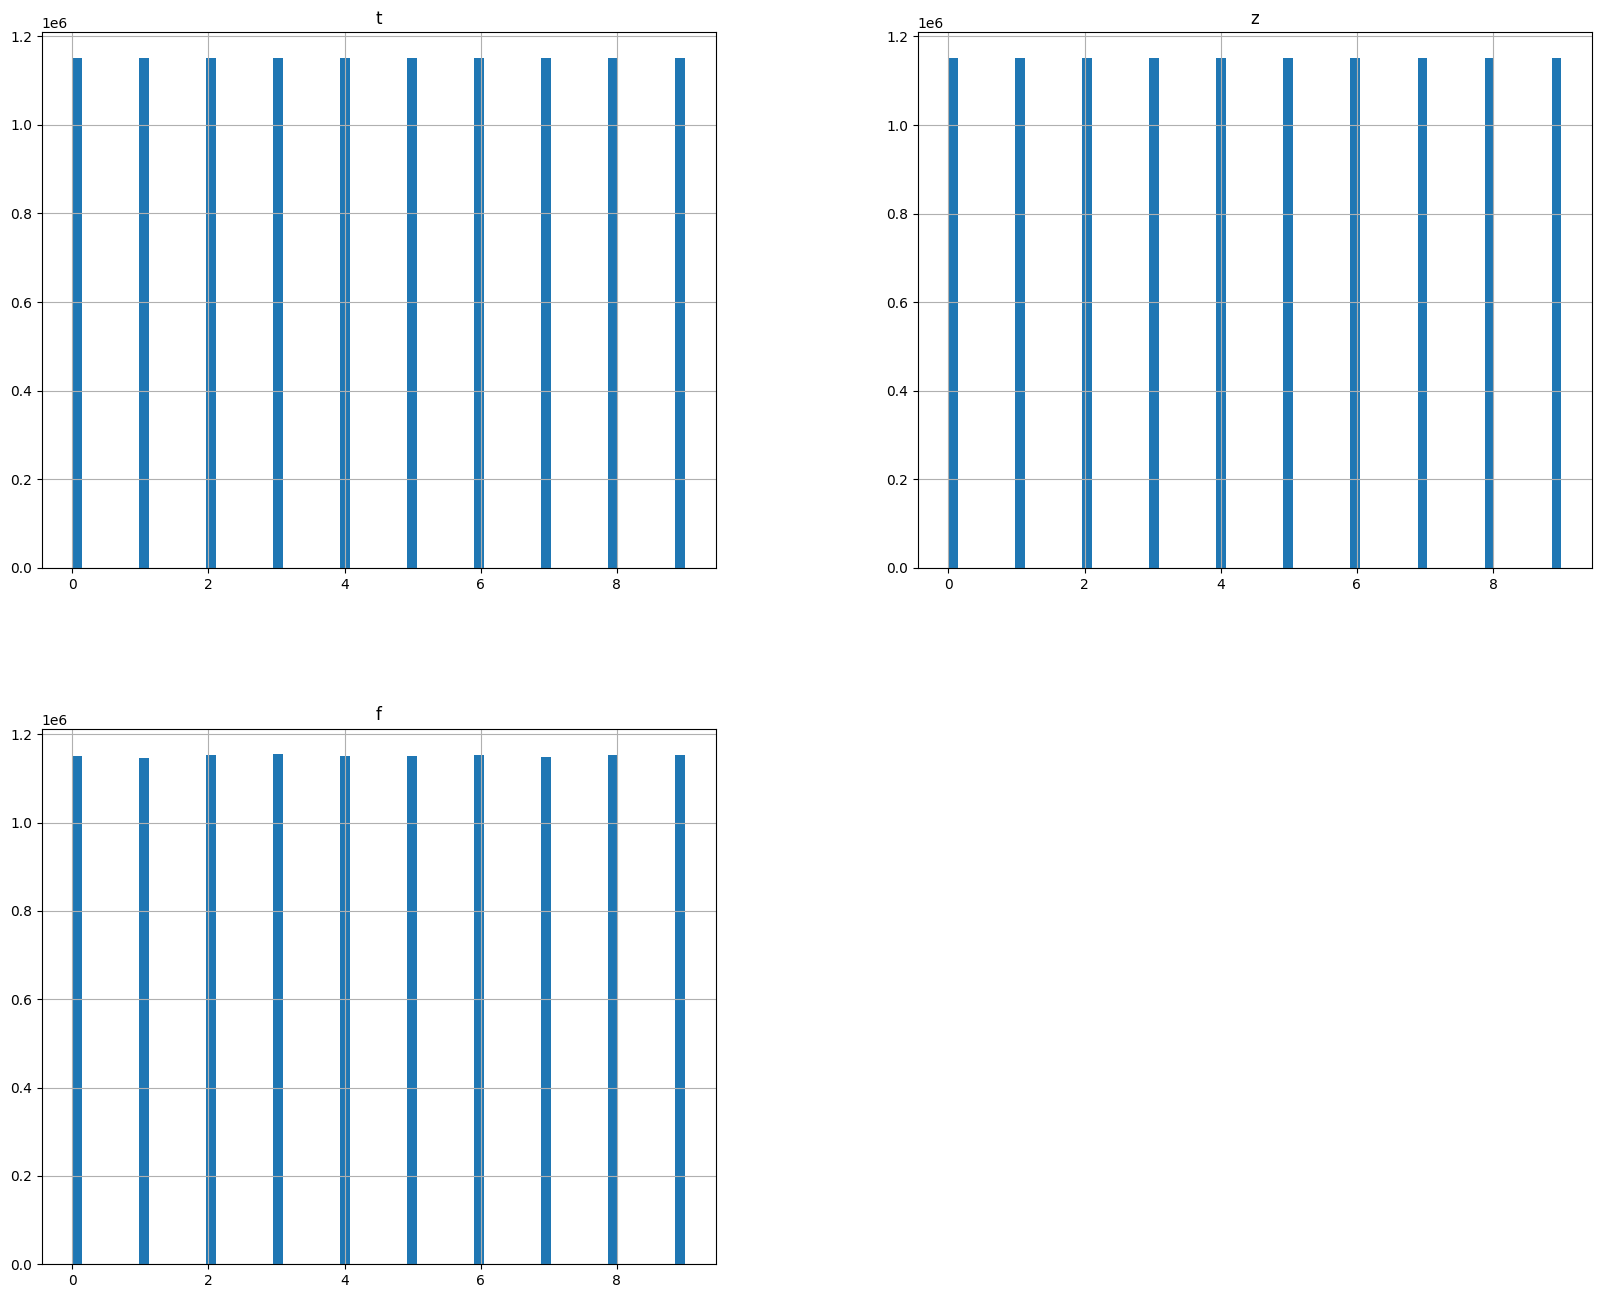

In [12]:
featureset_df.hist(figsize=(20,16), bins = 64)
plt.show()

In [13]:
X = pd.concat([featureset_df, df[['s', 'trial_id']]], axis=1)

In [14]:
Y = df.groupby(['trial_id', 'd', 'i', 'o'])['t'].shift(-1)

print(f"Label Statistics:")
print(f"Total rows: {len(Y)}")
print(f"Labeled rows: {Y.notna().sum()}")
print(f"Unlabeled rows (no future match): {Y.isna().sum()}")
print(f"Label coverage: {Y.notna().sum() / len(Y) * 100:.2f}%")

Label Statistics:
Total rows: 11511970
Labeled rows: 10716133
Unlabeled rows (no future match): 795837
Label coverage: 93.09%


In [15]:
Y.fillna(1e15, inplace=True)

In [16]:
N_CLASSES = 5
Y_binned, Y_discritizer = train_and_transform_discretizer(Y.to_frame(), n_bins=N_CLASSES, strategy='quantile')

array([[<Axes: title={'center': 't'}>]], dtype=object)

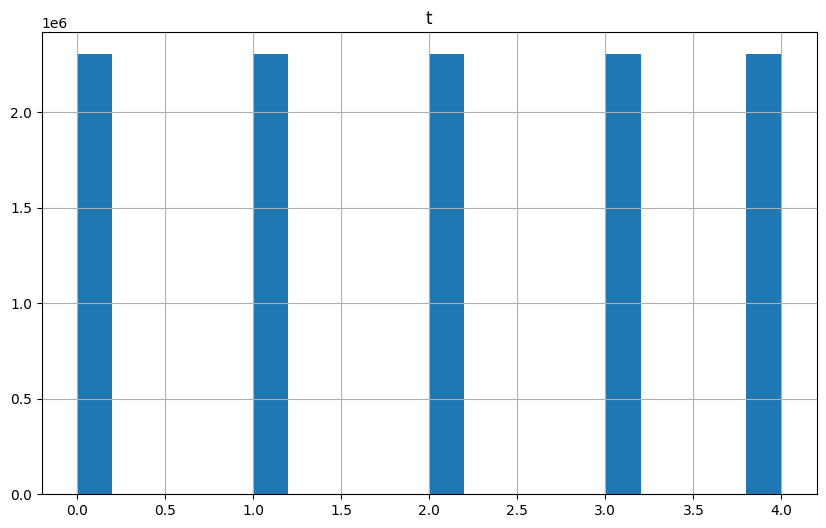

In [17]:
Y_binned.hist(figsize=(10,6), bins=20)

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_binned, test_size=0.2, random_state=42, stratify=Y_binned
)

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
Y_train_np = Y_train.to_numpy().ravel()
Y_test_np = Y_test.to_numpy().ravel()

n_features = X_train_np.shape[1]

print(f"\nData Summary:")
print(f"  Features: {n_features}")
print(f"  Classes: {N_CLASSES}")
print(f"  Training samples: {len(X_train_np)}")
print(f"  Test samples: {len(X_test_np)}")


Data Summary:
  Features: 5
  Classes: 5
  Training samples: 9209576
  Test samples: 2302394


In [19]:
import numpy as np
import keras
from keras import layers
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import sys
sys.path.append('..')
from learnedcache.activations import Squaremax, TaylorSoftmax

In [20]:
from learnedcache.layers import FeatureOneHotEncoder
import keras.ops as ops

n_bins_list = [len(discretizer.bin_edges_[i]) - 1 for i in range(3)]
print(f"Actual bins per feature: {n_bins_list}")

inputs = layers.Input(shape=(n_features,))

split_tensors = ops.split(inputs, [3], axis=1)
discretized_features = split_tensors[0]
other_features = split_tensors[1]

encoded = FeatureOneHotEncoder(n_bins_list)(discretized_features)

combined = layers.Concatenate()([encoded, other_features])

output = layers.Dense(N_CLASSES)(combined)
output = Squaremax()(output)

model = keras.Model(inputs=inputs, outputs=output, name="LearnedCache_squaremax")

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_np, Y_train_np,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_np, Y_test_np),
    callbacks=[early_stop],
    verbose=1
)

Y_pred_prob = model.predict(X_test_np, verbose=0)
Y_pred = np.argmax(Y_pred_prob, axis=1)
accuracy = accuracy_score(Y_test_np, Y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Trained for {len(history.history['loss'])} epochs (early stopping)")
print("\nClassification Report:")
print(classification_report(Y_test_np, Y_pred))

print("\nPer-Class Accuracy:")
for i in range(N_CLASSES):
    mask = Y_test_np == i
    if mask.sum() > 0:
        class_acc = (Y_pred[mask] == i).sum() / mask.sum()
        print(f"  Class {i}: {class_acc:.4f} ({mask.sum()} samples)")

fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 3, 2)
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(1, 3, 3)
cm = confusion_matrix(Y_test_np, Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3)
ax3.set_title(f'Confusion Matrix\nAccuracy: {accuracy:.4f}')
ax3.set_ylabel('True Class')
ax3.set_xlabel('Predicted Class')

plt.tight_layout()
plt.show()


Actual bins per feature: [10, 10, 10]


Model: "LearnedCache_squaremax"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split (Split)       │ [(None, 3),       │          0 │ input_layer[0][0] │
│                     │ (None, 2)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_one_hot_en… │ (None, 30)        │          0 │ split[0][0]       │
│ (FeatureOneHotEnco… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32)        │          0 │ feature_one_hot_… │
│ (Concatenate)       │                   │            │ split[0][1]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 5)         │        165 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ squaremax           │ (None, 5)         │          0 │ dense[0][0]       │
│ (Squaremax)         │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
 67616/287800 ━━━━━━━━━━━━━━━━━━━━ 1:21 370us/step - accuracy: 0.2116 - loss: 4.4456

KeyboardInterrupt: 

Actual bins per feature: [10, 10, 5]


Model: "LearnedCache_taylorsoftmax"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_3 (Split)     │ [(None, 3),       │          0 │ input_layer_3[0]… │
│                     │ (None, 2)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_one_hot_en… │ (None, 25)        │          0 │ split_3[0][0]     │
│ (FeatureOneHotEnco… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 27)        │          0 │ feature_one_hot_… │
│ (Concatenate)       │                   │            │ split_3[0][1]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │        140 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ taylor_softmax      │ (None, 5)         │          0 │ dense_3[0][0]     │
│ (TaylorSoftmax)     │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 140 (560.00 B)

 Trainable params: 140 (560.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
321939/321939 ━━━━━━━━━━━━━━━━━━━━ 148s 459us/step - accuracy: 0.2285 - loss: 1.6033 - val_accuracy: 0.2289 - val_loss: 1.6028
Epoch 2/5
321939/321939 ━━━━━━━━━━━━━━━━━━━━ 148s 458us/step - accuracy: 0.2286 - loss: 1.6029 - val_accuracy: 0.2294 - val_loss: 1.6028
Epoch 3/5
321939/321939 ━━━━━━━━━━━━━━━━━━━━ 150s 466us/step - accuracy: 0.2287 - loss: 1.6030 - val_accuracy: 0.2294 - val_loss: 1.6029
Epoch 4/5
321939/321939 ━━━━━━━━━━━━━━━━━━━━ 148s 459us/step - accuracy: 0.2285 - loss: 1.6029 - val_accuracy: 0.2291 - val_loss: 1.6028
Epoch 5/5
321939/321939 ━━━━━━━━━━━━━━━━━━━━ 148s 457us/step - accuracy: 0.2287 - loss: 1.6029 - val_accuracy: 0.2285 - val_loss: 1.6029
Restoring model weights from the end of the best epoch: 4.

Test Accuracy: 0.2291
Trained for 5 epochs (early stopping)

Classification Report:
              precision    recall  f1-score   support

         0.0       0.22      0.27      0.24    515101
         1.0       0.22      0.19      0.20    515101
        

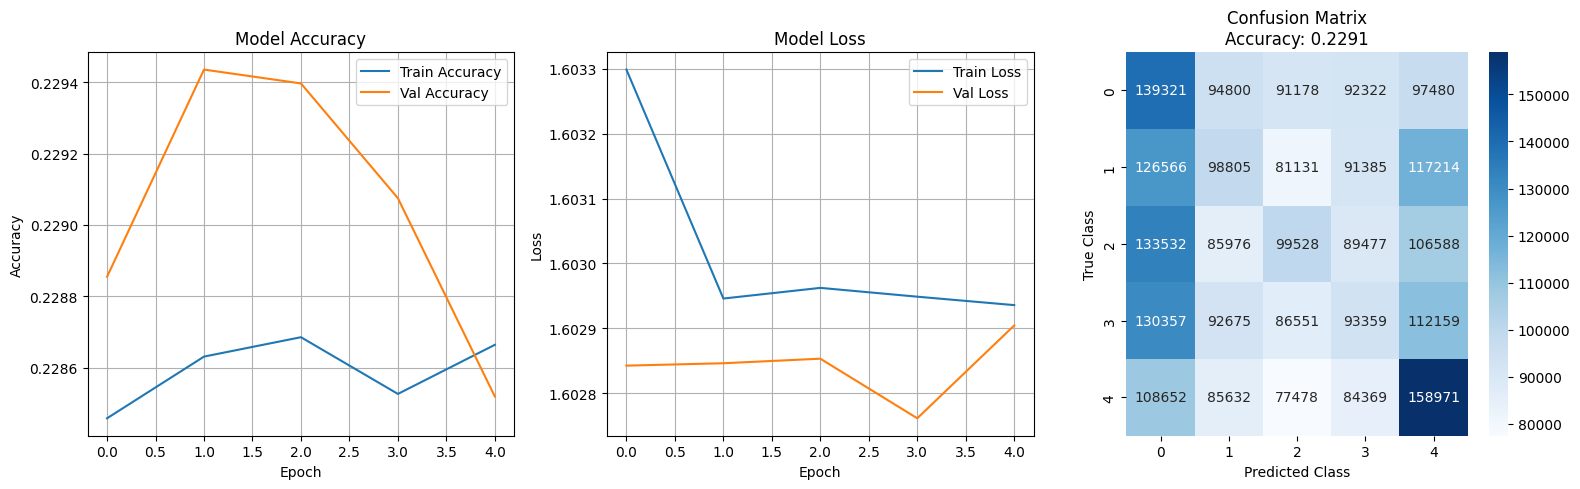

In [ ]:
from learnedcache.layers import FeatureOneHotEncoder
import keras.ops as ops

n_bins_list = [len(discretizer.bin_edges_[i]) - 1 for i in range(3)]
print(f"Actual bins per feature: {n_bins_list}")

inputs = layers.Input(shape=(n_features,))

split_tensors = ops.split(inputs, [3], axis=1)
discretized_features = split_tensors[0]
other_features = split_tensors[1]

encoded = FeatureOneHotEncoder(n_bins_list)(discretized_features)

combined = layers.Concatenate()([encoded, other_features])

output = layers.Dense(N_CLASSES)(combined)
output = TaylorSoftmax()(output)

model = keras.Model(inputs=inputs, outputs=output, name="LearnedCache_taylorsoftmax")

model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model.summary()

early_stop = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
)

history = model.fit(
    X_train_np,
    Y_train_np,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_np, Y_test_np),
    callbacks=[early_stop],
    verbose=1,
)

Y_pred_prob = model.predict(X_test_np, verbose=0)
Y_pred = np.argmax(Y_pred_prob, axis=1)
accuracy = accuracy_score(Y_test_np, Y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Trained for {len(history.history['loss'])} epochs (early stopping)")
print("\nClassification Report:")
print(classification_report(Y_test_np, Y_pred))

print("\nPer-Class Accuracy:")
for i in range(N_CLASSES):
    mask = Y_test_np == i
    if mask.sum() > 0:
        class_acc = (Y_pred[mask] == i).sum() / mask.sum()
        print(f"  Class {i}: {class_acc:.4f} ({mask.sum()} samples)")

fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.plot(history.history["accuracy"], label="Train Accuracy")
ax1.plot(history.history["val_accuracy"], label="Val Accuracy")
ax1.set_title("Model Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 3, 2)
ax2.plot(history.history["loss"], label="Train Loss")
ax2.plot(history.history["val_loss"], label="Val Loss")
ax2.set_title("Model Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(1, 3, 3)
cm = confusion_matrix(Y_test_np, Y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3)
ax3.set_title(f"Confusion Matrix\nAccuracy: {accuracy:.4f}")
ax3.set_ylabel("True Class")
ax3.set_xlabel("Predicted Class")

plt.tight_layout()
plt.show()

n_bins_list: [10, 10, 5]


Model: "LearnedCache_binary_slp"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_4 (Split)     │ [(None, 3),       │          0 │ input_layer_4[0]… │
│                     │ (None, 2)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_one_hot_en… │ (None, 25)        │          0 │ split_4[0][0]     │
│ (FeatureOneHotEnco… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 27)        │          0 │ feature_one_hot_… │
│ (Concatenate)       │                   │            │ split_4[0][1]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         28 │ concatenate_4[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28 (112.00 B)

 Trainable params: 28 (112.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
321939/321939 ━━━━━━━━━━━━━━━━━━━━ 131s 404us/step - AUC: 0.5266 - accuracy: 0.5197 - loss: 0.6918 - val_AUC: 0.5280 - val_accuracy: 0.5212 - val_loss: 0.6917
Epoch 2/5
321939/321939 ━━━━━━━━━━━━━━━━━━━━ 131s 405us/step - AUC: 0.5269 - accuracy: 0.5198 - loss: 0.6917 - val_AUC: 0.5263 - val_accuracy: 0.5181 - val_loss: 0.6919
Epoch 3/5
321939/321939 ━━━━━━━━━━━━━━━━━━━━ 131s 407us/step - AUC: 0.5268 - accuracy: 0.5199 - loss: 0.6918 - val_AUC: 0.5280 - val_accuracy: 0.5212 - val_loss: 0.6916
Epoch 4/5
321939/321939 ━━━━━━━━━━━━━━━━━━━━ 130s 404us/step - AUC: 0.5270 - accuracy: 0.5200 - loss: 0.6918 - val_AUC: 0.5268 - val_accuracy: 0.5174 - val_loss: 0.6918
Epoch 5/5
321939/321939 ━━━━━━━━━━━━━━━━━━━━ 1062s 3ms/step - AUC: 0.5269 - accuracy: 0.5199 - loss: 0.6918 - val_AUC: 0.5266 - val_accuracy: 0.5196 - val_loss: 0.6918
Restoring model weights from the end of the best epoch: 3.


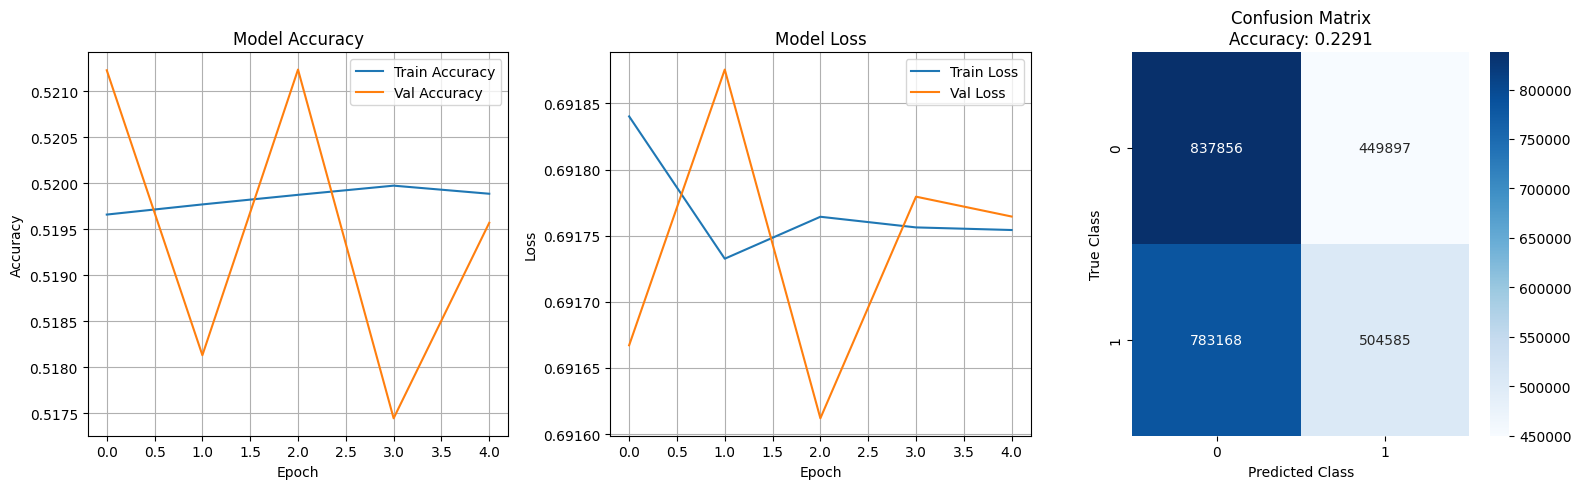

In [ ]:
Y_binary = (Y >= Y.quantile(0.5)).astype(int)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_binary, test_size=0.2, random_state=42, stratify=Y_binary
)
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
Y_train_np = Y_train.to_numpy().ravel()
Y_test_np = Y_test.to_numpy().ravel()

n_bins_list = [len(discretizer.bin_edges_[i]) - 1 for i in range(3)]
print("n_bins_list:", n_bins_list)

from learnedcache.layers import FeatureOneHotEncoder
from keras import layers
from keras.callbacks import EarlyStopping
import keras

inputs = layers.Input(shape=(n_features,))

split_tensors = ops.split(inputs, [3], axis=1)
discretized = split_tensors[0]
other_features = split_tensors[1]

encoded = FeatureOneHotEncoder(n_bins_list)(discretized)
combined = layers.Concatenate()([encoded, other_features])

output = layers.Dense(1, activation="sigmoid")(combined)

model = keras.Model(inputs=inputs, outputs=output, name="LearnedCache_binary_slp")
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", "AUC"])
model.summary()

early_stop = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
)

binary_history = model.fit(
    X_train_np,
    Y_train_np,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_np, Y_test_np),
    callbacks=[early_stop],
    verbose=1,
)

y_prob = model.predict(X_test_np, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.plot(binary_history.history["accuracy"], label="Train Accuracy")
ax1.plot(binary_history.history["val_accuracy"], label="Val Accuracy")
ax1.set_title("Model Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 3, 2)
ax2.plot(binary_history.history["loss"], label="Train Loss")
ax2.plot(binary_history.history["val_loss"], label="Val Loss")
ax2.set_title("Model Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(1, 3, 3)
cm = confusion_matrix(Y_test_np, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3)
ax3.set_title(f"Confusion Matrix\nAccuracy: {accuracy:.4f}")
ax3.set_ylabel("True Class")
ax3.set_xlabel("Predicted Class")

plt.tight_layout()
plt.show()

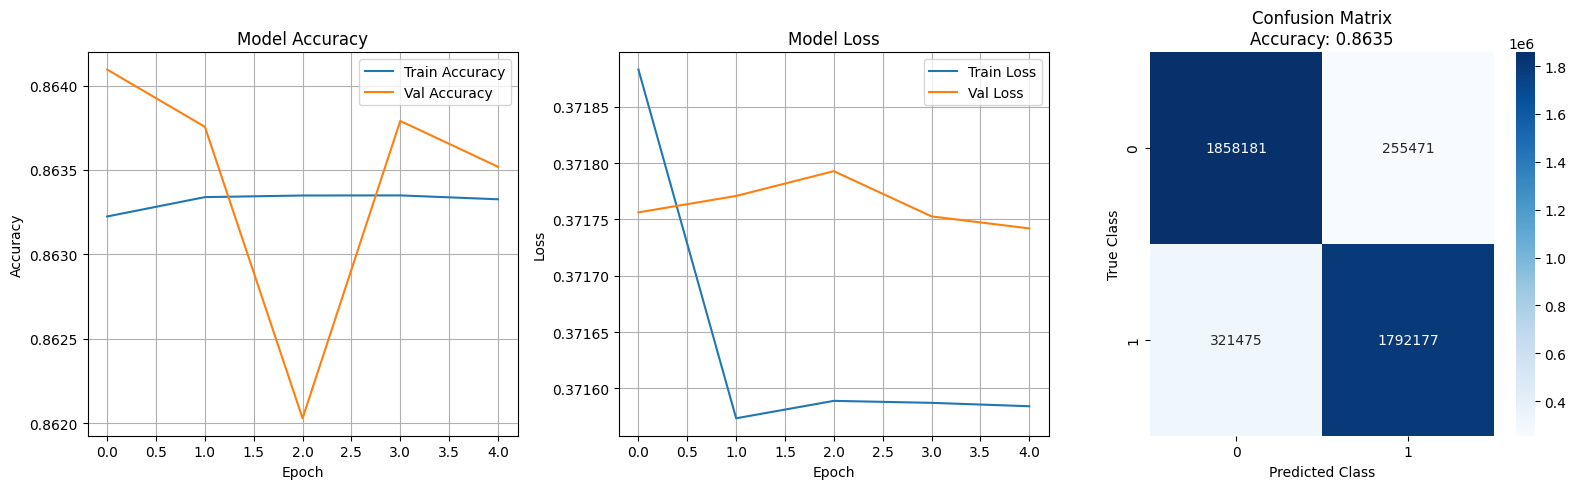

In [ ]:
accuracy = accuracy_score(Y_test_np, y_pred)

fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.plot(binary_history.history["accuracy"], label="Train Accuracy")
ax1.plot(binary_history.history["val_accuracy"], label="Val Accuracy")
ax1.set_title("Model Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 3, 2)
ax2.plot(binary_history.history["loss"], label="Train Loss")
ax2.plot(binary_history.history["val_loss"], label="Val Loss")
ax2.set_title("Model Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(1, 3, 3)
cm = confusion_matrix(Y_test_np, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3)
ax3.set_title(f"Confusion Matrix\nAccuracy: {accuracy:.4f}")
ax3.set_ylabel("True Class")
ax3.set_xlabel("Predicted Class")

plt.tight_layout()
plt.show()